In [1]:
import numpy as np
import matplotlib.pyplot as plt

Z = np.load("outputs/vision_level_tokens.npy")        # actual Vision Agent output
z = np.load("outputs/vision_pooled_embeddings.npy")   # pooled vector used for global InfoNCE

print("level tokens:", Z.shape, Z.dtype)      # [N, K, d]
print("pooled:", z.shape, z.dtype)            # [N, d]
print("pooled norms:", np.linalg.norm(z, axis=1).mean(), np.linalg.norm(z, axis=1).std())

level tokens: (130, 10, 64) float32
pooled: (130, 64) float32
pooled norms: 1.0 6.338217e-08


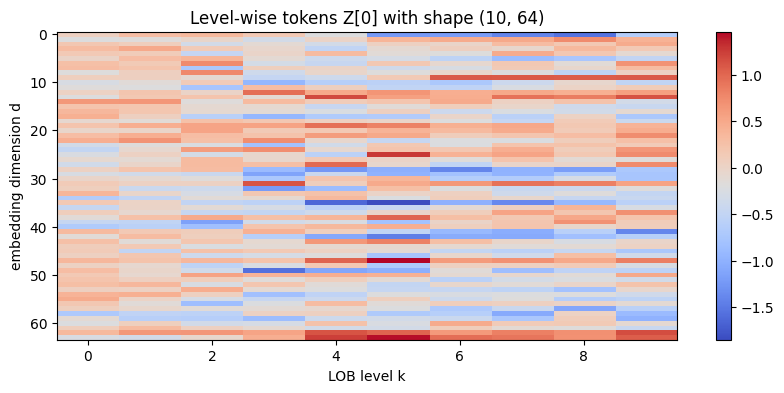

In [2]:
i = 0  # snapshot index

plt.figure(figsize=(10, 4))
plt.imshow(Z[i].T, aspect="auto", cmap="coolwarm")
plt.colorbar()
plt.xlabel("LOB level k")
plt.ylabel("embedding dimension d")
plt.title(f"Level-wise tokens Z[{i}] with shape {Z[i].shape}")
plt.show()

In [3]:
S = z @ z.T  # pooled vectors are L2-normalized

i = 0
nearest = np.argsort(-S[i])[1:6]
print("query snapshot:", i)
print("nearest:", nearest)
print("similarities:", S[i, nearest])

query snapshot: 0
nearest: [25 12 11 30 33]
similarities: [0.87657213 0.8753429  0.8659433  0.85797524 0.8565285 ]


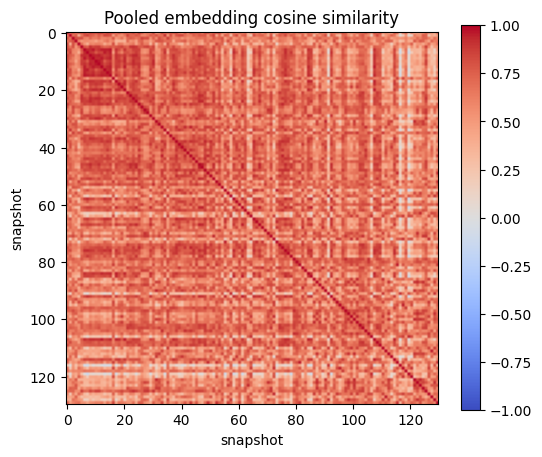

In [4]:
plt.figure(figsize=(6, 5))
plt.imshow(S, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.title("Pooled embedding cosine similarity")
plt.xlabel("snapshot")
plt.ylabel("snapshot")
plt.show()

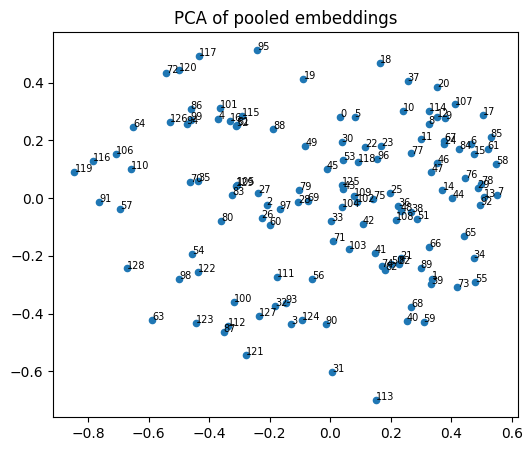

In [5]:
X = z - z.mean(axis=0, keepdims=True)
_, _, vt = np.linalg.svd(X, full_matrices=False)
xy = X @ vt[:2].T

plt.figure(figsize=(6, 5))
plt.scatter(xy[:, 0], xy[:, 1], s=20)
for i in range(len(xy)):
    plt.text(xy[i, 0], xy[i, 1], str(i), fontsize=7)
plt.title("PCA of pooled embeddings")
plt.show()